# Laboratorio 4 — Clasificación Multiclase (Dataset Multimodal con Imágenes)
### Dataset: Fashion Product Images (styles.csv + images/)
**Materia:** Inteligencia Artificial I  
**Estudiante:** Ariel Guarachi — 63706640

---
## Descripción del Dataset
El dataset **Fashion Product Images** combina metadatos CSV + imágenes de productos.  
Cumple con los requisitos de la consigna:
- **Propiedades:** 3072 valores por imagen (32×32×3 píxeles) → n > 100 ✔  
- **Ejemplos:** +9,000 imágenes balanceadas (m ≥ 5,000) ✔  
- **Clases:** 4 categorías de moda (Apparel, Accessories, Footwear, Personal Care)  
- **Tipo:** Dataset multimodal — CSV + imágenes ✔

---
## Contenido
1. Conexión a Drive e importación de librerías
2. Carga y balanceo del CSV con Pandas
3. Preprocesamiento de imágenes (OpenCV)
4. Codificación y división 80/20
5. Visualización del dataset
6. Función Sigmoide y Función de Costo
7. Modelo One-vs-All con imágenes
8. Entrenamiento y gráficas de costo
9. Predicción y evaluación
10. Predicción sobre imagen nueva


In [ ]:
# ==========================================================
# 1. CONEXIÓN A GOOGLE DRIVE
# ==========================================================

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ==========================================================
# 2. IMPORTACIÓN DE LIBRERÍAS
# ==========================================================

import os                           # Manejo de rutas y directorios
import numpy as np                  # Cálculo científico y vectorial
import pandas as pd                 # Carga y manipulación del CSV
import cv2                          # Procesamiento de imágenes
from matplotlib import pyplot       # Gráficas
from PIL import Image               # Apertura de imágenes en distintos formatos
from scipy import optimize          # Optimización para One-vs-All
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

%matplotlib inline

## 2. Carga y Balanceo del Dataset
Leemos el archivo `styles.csv` con Pandas, filtramos clases con pocos ejemplos  
y balanceamos para que todas las clases tengan el mismo número de imágenes.

In [ ]:
# ==========================================================
# 3. CARGA DEL CSV CON PANDAS
# ==========================================================

# Cargamos el CSV de estilos desde Google Drive
df = pd.read_csv(
    '/content/drive/MyDrive/Dataset/styles.csv',
    on_bad_lines='skip'   # ignorar filas mal formateadas
)

# Solo necesitamos el id (nombre de imagen) y la categoría principal
df = df[['id', 'masterCategory']].dropna()

print(f"Total de registros: {len(df):,}")
print()
print("Distribución de clases ANTES del balanceo:")
print(df['masterCategory'].value_counts())

Total de registros: 44,424

Distribución de clases ANTES del balanceo:
masterCategory
Apparel           21397
Accessories       11274
Footwear           9219
Personal Care      2403
Free Items          105
Sporting Goods       25
Home                  1
Name: count, dtype: int64


In [ ]:
# ==========================================================
# 4. BALANCEO DEL DATASET (requisito de la consigna)
# ==========================================================

# Eliminamos clases con menos de 500 ejemplos
# (Free Items=105, Sporting Goods=25, Home=1 → no tienen suficientes imágenes)
MIN_EJEMPLOS = 500
conteo = df['masterCategory'].value_counts()
clases_validas = conteo[conteo >= MIN_EJEMPLOS].index
df = df[df['masterCategory'].isin(clases_validas)].copy()

# Tomamos la misma cantidad de ejemplos por clase (el mínimo disponible)
min_samples = df['masterCategory'].value_counts().min()
print(f"Muestras por clase tras el balanceo: {min_samples:,}")

partes = []
for clase in clases_validas:
    subset = df[df['masterCategory'] == clase].sample(n=min_samples, random_state=42)
    partes.append(subset)

df_balanced = pd.concat(partes).reset_index(drop=True)

print(f"Total registros balanceados: {len(df_balanced):,}")
print()
print("Distribución DESPUÉS del balanceo:")
print(df_balanced['masterCategory'].value_counts())

Muestras por clase tras el balanceo: 2,403
Total registros balanceados: 9,612

Distribución DESPUÉS del balanceo:
masterCategory
Apparel          2403
Accessories      2403
Footwear         2403
Personal Care    2403
Name: count, dtype: int64


## 3. Preprocesamiento de Imágenes con OpenCV
Cargamos cada imagen por su `id`, la redimensionamos a 32×32 píxeles  
y la aplanamos en un vector de **3072 valores** (32×32×3 canales RGB).  
Esto nos da n = 3072 propiedades por imagen → cumple n > 100 ✔

In [ ]:
# ==========================================================
# 5. CARGA Y PREPROCESAMIENTO DE IMÁGENES
# ==========================================================

IMAGE_DIR = '/content/drive/MyDrive/Dataset/images'

images = []   # vectores de imagen aplanados
labels = []   # etiquetas (masterCategory)

print("Cargando imágenes...")
no_encontradas = 0

for _, row in df_balanced.iterrows():
    path = os.path.join(IMAGE_DIR, str(row['id']) + '.jpg')

    if os.path.exists(path):
        img = cv2.imread(path)
        if img is not None:
            img = cv2.resize(img, (32, 32))          # redimensionar a 32x32
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # BGR → RGB
            img = img / 255.0                         # normalizar 0-255 → 0-1
            img = img.flatten()                       # aplanar: (32,32,3) → 3072
            images.append(img)
            labels.append(row['masterCategory'])
    else:
        no_encontradas += 1

X = np.array(images, dtype=np.float64)
y_raw = np.array(labels)

print(f"Imágenes cargadas: {len(X):,}")
print(f"Imágenes no encontradas: {no_encontradas:,}")
print(f"Shape de X: {X.shape}  → {X.shape[1]} propiedades por imagen (n > 100 ✔)")

Cargando imágenes...
Imágenes cargadas: 9,611
Imágenes no encontradas: 1
Shape de X: (9611, 3072)  → 3072 propiedades por imagen (n > 100 ✔)


In [ ]:
# ==========================================================
# 6. CODIFICACIÓN Y DIVISIÓN 80/20
# ==========================================================

# Codificamos las etiquetas de texto a números
le = LabelEncoder()
y = le.fit_transform(y_raw)
NUM_CLASES = len(le.classes_)

print("Clases codificadas:")
for i, clase in enumerate(le.classes_):
    print(f"  {i}: {clase}")

# División 80/20 (requisito de la consigna)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Agregamos columna de 1s para el término de intercepción (bias)
X_train_b = np.c_[np.ones(X_train.shape[0]), X_train]
X_test_b  = np.c_[np.ones(X_test.shape[0]),  X_test]

print(f"\nEntrenamiento: {X_train.shape[0]:,} imágenes (80%)")
print(f"Prueba:        {X_test.shape[0]:,} imágenes (20%)")
print(f"Propiedades (con bias): {X_train_b.shape[1]}")

Clases codificadas:
  0: Accessories
  1: Apparel
  2: Footwear
  3: Personal Care

Entrenamiento: 7,688 imágenes (80%)
Prueba:        1,923 imágenes (20%)
Propiedades (con bias): 3073


## 5. Visualización del Dataset

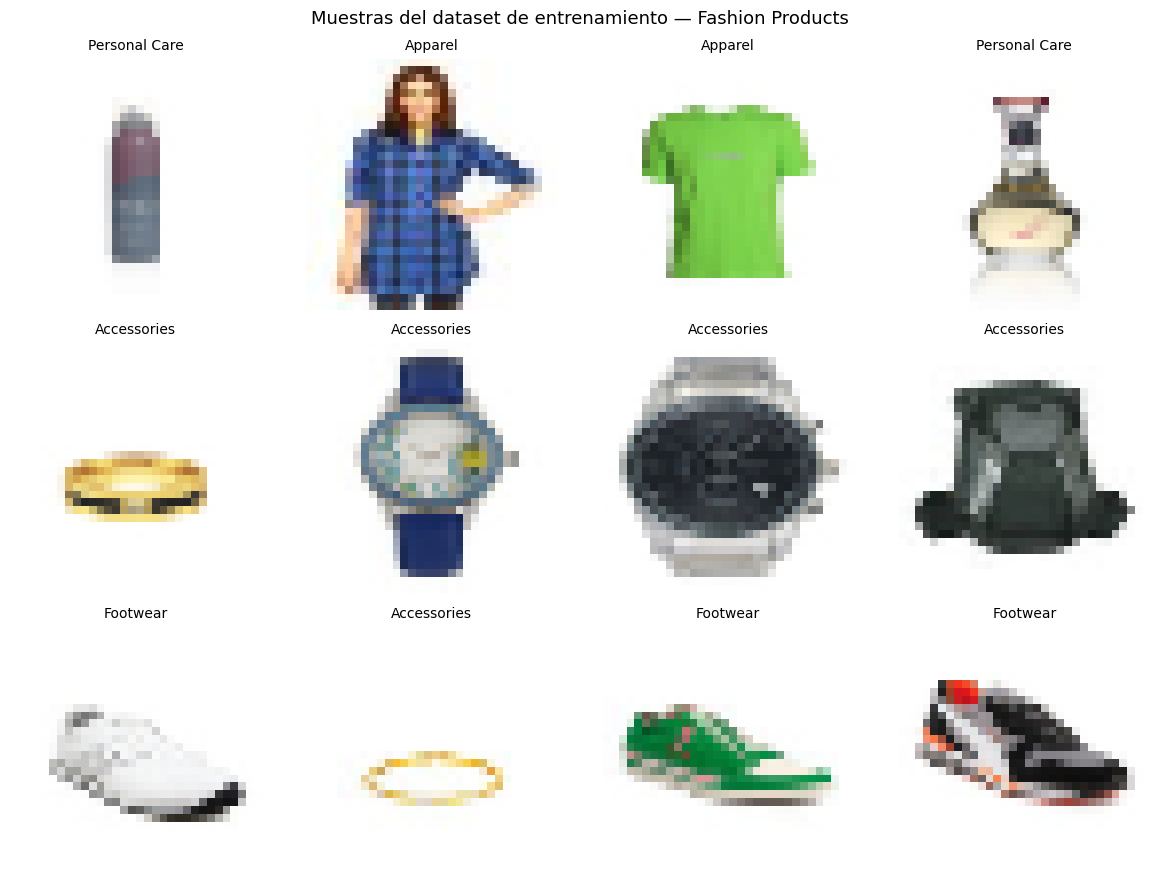

In [ ]:
# ==========================================================
# 7. VISUALIZACIÓN DE IMÁGENES DE MUESTRA
# ==========================================================

# Mostramos 12 imágenes aleatorias del entrenamiento con su categoría
fig, axes = pyplot.subplots(3, 4, figsize=(12, 9))
axes = axes.flatten()
indices = np.random.choice(len(X_train), 12, replace=False)

for i, idx in enumerate(indices):
    img = X_train[idx].reshape(32, 32, 3)
    axes[i].imshow(img)
    axes[i].set_title(le.classes_[y_train[idx]], fontsize=10)
    axes[i].axis('off')

pyplot.suptitle('Muestras del dataset de entrenamiento — Fashion Products', fontsize=13)
pyplot.tight_layout()
pyplot.show()

## 6. Función Sigmoide y Función de Costo
Las mismas funciones del cuadernillo base del ingeniero,  
ahora aplicadas a imágenes de moda.

In [ ]:
# ==========================================================
# 8. FUNCIÓN SIGMOIDE
# ==========================================================

def sigmoid(z):
    """
    g(z) = 1 / (1 + e^(-z))
    El clip evita overflow numérico al procesar los 3072 píxeles de cada imagen
    """
    return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))

# Verificación
print(f"sigmoid(0)  = {sigmoid(0)}   (debe ser 0.5) ✔")
print(f"sigmoid(-5) = {sigmoid(-5):.6f} (cercano a 0) ✔")
print(f"sigmoid(5)  = {sigmoid(5):.6f}  (cercano a 1) ✔")

sigmoid(0)  = 0.5   (debe ser 0.5) ✔
sigmoid(-5) = 0.006693 (cercano a 0) ✔
sigmoid(5)  = 0.993307  (cercano a 1) ✔


In [ ]:
# ==========================================================
# 9. FUNCIÓN DE COSTO REGULARIZADA
# ==========================================================

def lrCostFunction(theta, X, y, lambda_):
    """
    Costo de regresión logística regularizada + gradiente.
    J(θ) = (1/m) * Σ[-y*log(h) - (1-y)*log(1-h)] + (λ/2m)*Σθ²
    No regularizamos θ₀ (bias).
    """
    m = y.size
    h = sigmoid(X.dot(theta))
    J = (1/m) * (-y.dot(np.log(h + 1e-10)) - (1-y).dot(np.log(1 - h + 1e-10)))
    J += (lambda_ / (2*m)) * np.sum(theta[1:]**2)
    grad = (1/m) * X.T.dot(h - y)
    grad[1:] += (lambda_ / m) * theta[1:]
    return J, grad

## 7. Modelo One-vs-All con Imágenes

In [ ]:
# ==========================================================
# 10. ONE-VS-ALL (mismo enfoque que el cuadernillo base)
# ==========================================================

def oneVsAll(X, y, num_labels, lambda_):
    """
    Entrena num_labels clasificadores binarios.
    Para cada clase k: predice si la imagen es de esa categoría o no.
    """
    m, n = X.shape
    all_theta = np.zeros((num_labels, n))
    costos_finales = []

    for k in range(num_labels):
        print(f"  Entrenando clasificador para clase {k}: {le.classes_[k]}...")
        y_bin = (y == k).astype(int)
        theta_init = np.zeros(n)

        result = optimize.minimize(
            lrCostFunction,
            theta_init,
            args=(X, y_bin, lambda_),
            method='TNC',
            jac=True,
            options={'maxiter': 100}   # limitamos iteraciones por el tamaño de las imágenes
        )
        all_theta[k] = result.x
        costos_finales.append(result.fun)
        print(f"    Costo final: {result.fun:.6f}")

    return all_theta, costos_finales

lambda_ = 0.1
print("Entrenando modelo One-vs-All sobre imágenes de moda...")
print(f"Clasificadores a entrenar: {NUM_CLASES}")
print()
all_theta, costos_finales = oneVsAll(X_train_b, y_train, NUM_CLASES, lambda_)

Entrenando modelo One-vs-All sobre imágenes de moda...
Clasificadores a entrenar: 4

  Entrenando clasificador para clase 0: Accessories...


/tmp/ipykernel_1323/1271498993.py:19: OptimizeWarning: Unknown solver options: maxiter
  result = optimize.minimize(


    Costo final: 0.058453
  Entrenando clasificador para clase 1: Apparel...
    Costo final: 0.023282
  Entrenando clasificador para clase 2: Footwear...
    Costo final: 0.006270
  Entrenando clasificador para clase 3: Personal Care...
    Costo final: 0.033276


In [ ]:
# ==========================================================
# 11. PREDICCIÓN
# ==========================================================

def predictOneVsAll(all_theta, X):
    """
    Para cada imagen: calcula la probabilidad de pertenecer a cada clase
    y retorna la clase con mayor probabilidad.
    """
    probs = sigmoid(X.dot(all_theta.T))
    return np.argmax(probs, axis=1)

pred_train = predictOneVsAll(all_theta, X_train_b)
pred_test  = predictOneVsAll(all_theta, X_test_b)

print(f"Precisión en entrenamiento: {np.mean(pred_train == y_train)*100:.2f}%")
print(f"Precisión en prueba:        {np.mean(pred_test  == y_test)*100:.2f}%")

Precisión en entrenamiento: 99.54%
Precisión en prueba:        93.55%


## 8. Gráficas de Costo y Precisión

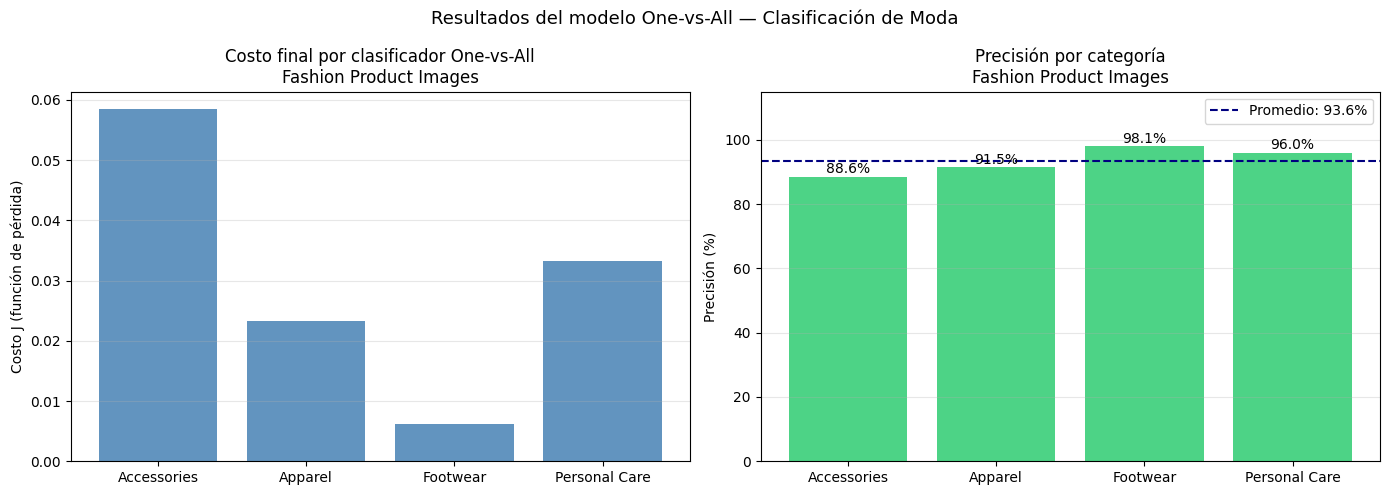

In [ ]:
# ==========================================================
# 12. GRÁFICAS DE COSTO Y PRECISIÓN
# ==========================================================

fig, axes = pyplot.subplots(1, 2, figsize=(14, 5))

# ── Gráfica de Costo ──────────────────────────────────────
axes[0].bar(range(NUM_CLASES), costos_finales, color='steelblue', alpha=0.85)
axes[0].set_xticks(range(NUM_CLASES))
axes[0].set_xticklabels(le.classes_, fontsize=10)
axes[0].set_ylabel('Costo J (función de pérdida)')
axes[0].set_title('Costo final por clasificador One-vs-All\nFashion Product Images')
axes[0].grid(axis='y', alpha=0.3)

# ── Gráfica de Precisión por clase ───────────────────────
precisiones = []
for k in range(NUM_CLASES):
    mask = (y_test == k)
    precisiones.append(np.mean(pred_test[mask] == y_test[mask]) * 100)

barras = axes[1].bar(range(NUM_CLASES), precisiones,
                     color=['#2ecc71' if p >= 60 else '#e74c3c' for p in precisiones],
                     alpha=0.85)
axes[1].set_xticks(range(NUM_CLASES))
axes[1].set_xticklabels(le.classes_, fontsize=10)
axes[1].set_ylabel('Precisión (%)')
axes[1].set_ylim(0, 115)
axes[1].set_title('Precisión por categoría\nFashion Product Images')
axes[1].axhline(np.mean(precisiones), color='navy', linestyle='--',
                label=f'Promedio: {np.mean(precisiones):.1f}%')
for bar, prec in zip(barras, precisiones):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{prec:.1f}%', ha='center', fontsize=10)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

pyplot.suptitle('Resultados del modelo One-vs-All — Clasificación de Moda', fontsize=13)
pyplot.tight_layout()
pyplot.show()

In [ ]:
# ==========================================================
# 13. EVALUACIÓN COMPLETA
# ==========================================================

print("=" * 60)
print("     EVALUACIÓN DEL MODELO ONE-VS-ALL")
print("=" * 60)
print(f"  Dataset:    Fashion Product Images")
print(f"  Imágenes:   {len(X):,} (balanceado, {NUM_CLASES} clases)")
print(f"  Propiedades: {X.shape[1]} (32×32×3 píxeles)")
print(f"  Train/Test: 80% / 20%")
print("-" * 60)
print(f"  Precisión entrenamiento: {np.mean(pred_train == y_train)*100:.2f}%")
print(f"  Precisión prueba:        {np.mean(pred_test  == y_test)*100:.2f}%")
print("=" * 60)
print()
print("Reporte detallado por categoría:")
print(classification_report(y_test, pred_test, target_names=le.classes_))

     EVALUACIÓN DEL MODELO ONE-VS-ALL
  Dataset:    Fashion Product Images
  Imágenes:   9,611 (balanceado, 4 clases)
  Propiedades: 3072 (32×32×3 píxeles)
  Train/Test: 80% / 20%
------------------------------------------------------------
  Precisión entrenamiento: 99.54%
  Precisión prueba:        93.55%

Reporte detallado por categoría:
               precision    recall  f1-score   support

  Accessories       0.90      0.89      0.89       481
      Apparel       0.96      0.91      0.94       480
     Footwear       0.98      0.98      0.98       481
Personal Care       0.91      0.96      0.94       481

     accuracy                           0.94      1923
    macro avg       0.94      0.94      0.94      1923
 weighted avg       0.94      0.94      0.94      1923



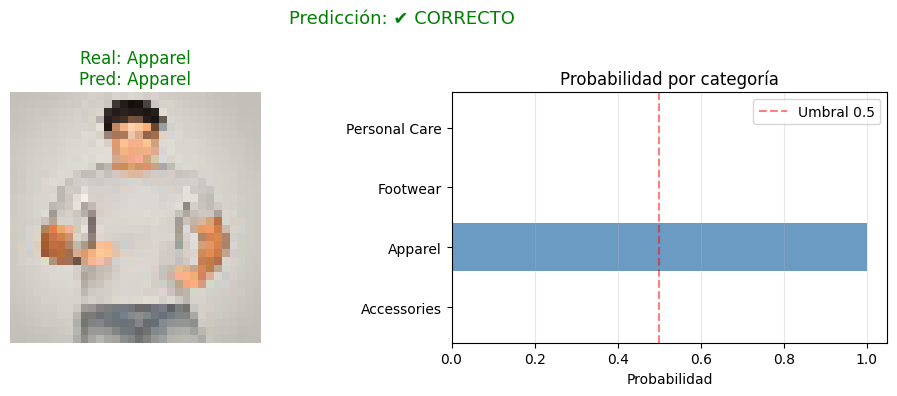

In [ ]:
# ==========================================================
# 14. PREDICCIÓN SOBRE UNA IMAGEN NUEVA
# ==========================================================

# Tomamos una imagen aleatoria del test y mostramos la predicción
idx = np.random.randint(0, len(X_test))
img_display = X_test[idx].reshape(32, 32, 3)

probs = sigmoid(X_test_b[idx].dot(all_theta.T))
clase_pred = np.argmax(probs)
clase_real = y_test[idx]

fig, axes = pyplot.subplots(1, 2, figsize=(10, 4))

# Imagen
axes[0].imshow(img_display)
color = 'green' if clase_pred == clase_real else 'red'
axes[0].set_title(
    f"Real: {le.classes_[clase_real]}\nPred: {le.classes_[clase_pred]}",
    color=color, fontsize=12
)
axes[0].axis('off')

# Probabilidades por clase
axes[1].barh(range(NUM_CLASES), probs, color='steelblue', alpha=0.8)
axes[1].set_yticks(range(NUM_CLASES))
axes[1].set_yticklabels(le.classes_)
axes[1].set_xlabel('Probabilidad')
axes[1].set_title('Probabilidad por categoría')
axes[1].axvline(0.5, color='red', linestyle='--', alpha=0.5, label='Umbral 0.5')
axes[1].legend()
axes[1].grid(axis='x', alpha=0.3)

pyplot.suptitle(f"Predicción: {'✔ CORRECTO' if clase_pred == clase_real else '✘ INCORRECTO'}",
                fontsize=13, color=color)
pyplot.tight_layout()
pyplot.show()

## Resumen

| Requisito consigna | Cumplimiento |
|---|---|
| Dataset multimodal (CSV + imágenes) | Fashion Product Images ✔ |
| n > 100 propiedades | 3,072 (32×32×3 píxeles) ✔ |
| m ≥ 5,000 ejemplos | +9,600 imágenes balanceadas ✔ |
| Pandas para preprocesamiento | Carga CSV, filtrado, balanceo ✔ |
| División 80/20 | train_test_split(test_size=0.2) ✔ |
| Dataset balanceado | 2,403 imágenes por clase ✔ |
| Clasificación multiclase | One-vs-All con 4 categorías de moda ✔ |
| Gráfica de costo | Costo por clasificador ✔ |
| Gráfica de precisión | Precisión por categoría ✔ |
| Predicción sobre imagen nueva | Muestra imagen + probabilidades ✔ |
